# 04a — EnKF Innovation and Kalman-Gain Decomposition

**Pipeline stage 4a of 9.** Diagnoses the EnKF preprocessor by running it directly on the driver observations and computing the standard data-assimilation decomposition: per-step innovations, Kalman gains, forecast-vs-analysis variance reduction, and Desroziers (2005) consistency checks against the assumed Q and R.

**Why this exists.** Notebook 01 ran the EnKF as a black-box preprocessor and saved only the denoised mean. The Q and R matrices logged in `ENKF_PREPROCESSOR_NOISE_PATH` are *assumed* values from `estimate_enkf_noise` — they have not been verified against the empirical innovations the EnKF actually produced. This notebook does that verification and produces the methods-section figure showing what the EnKF is doing on the driver state.

**Outputs (`output_refactored/enkf_decomposition/`)**
- `Fig4a_innovations_time_series.png/.pdf` — per-driver innovation series with ±√R bands
- `Fig4b_kalman_gain_time_series.png/.pdf` — Kalman gain magnitude over time per driver
- `Fig4c_variance_reduction.png/.pdf` — trace(P^f) vs trace(P^a) and reduction ratio
- `Fig4d_desroziers_consistency.png/.pdf` — empirical-vs-assumed innovation and R consistency
- `Table4a_innovation_summary.csv` — innovation RMSE/bias per driver
- `Table4b_kalman_gain_summary.csv` — gain statistics per driver
- `Table4c_variance_reduction_summary.csv` — variance reduction by data split
- `Table4d_desroziers_consistency.csv` — consistency ratios with 95% bootstrap CIs

**Artifact persistence (`output_refactored/intermediate/`)**
- `enkf_diagnostics.npz` — the EnKF ensemble members, per-step P^f/P^a diagonals, innovations, and gains. Notebook 04b consumes the ensemble members from this file to build the 3-D MC-dropout tensor.


## Setup

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shared_config import *
print_config_summary()

SEED = 42
np.random.seed(SEED)

DECOMPOSITION_DIR = os.path.join(OUTPUT_DIR, "enkf_decomposition")
os.makedirs(DECOMPOSITION_DIR, exist_ok=True)
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

plt.rcdefaults()
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def savefig(fig, stem):
    for ext in ("png", "pdf"):
        fp = os.path.join(DECOMPOSITION_DIR, f"{stem}.{ext}")
        fig.savefig(fp, dpi=300, bbox_inches="tight")
        print(f"  saved {fp}")


def display_df(df):
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


def save_table(df, fname, title=None):
    fp = os.path.join(DECOMPOSITION_DIR, fname)
    df.to_csv(fp, index=False)
    print(f"  saved {fp}")
    if title:
        print(f"  {title}")
    display_df(df)


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load EnKF configuration and chronological splits

Reads the Q and R diagonal that notebook 01 estimated from training data (via
`estimate_enkf_noise`) and the chronologically-ordered raw splits so we can run
the EnKF on the same observation series the preprocessor saw.

In [2]:
with open(ENKF_PREPROCESSOR_NOISE_PATH) as f:
    enkf_config = json.load(f)

state_vars = list(enkf_config["state_vars"])
Q_diag = np.asarray(enkf_config["Q_diag"], dtype=float)
R_diag = np.asarray(enkf_config["R_diag"], dtype=float)
N_ENKF_CFG = int(enkf_config.get("n_enkf", 50))

print(f"State variables ({len(state_vars)}): {state_vars}")
print(f"Q diagonal: {Q_diag}")
print(f"R diagonal: {R_diag}")
print(f"Ensemble size (from notebook 01 config): {N_ENKF_CFG}")

# RAW (pre-EnKF) chronological splits are what the EnKF preprocessor observed.
train_df = pd.read_parquet(TRAIN_DF_PATH)
val_df = pd.read_parquet(VAL_DF_PATH)
test_df = pd.read_parquet(TEST_DF_PATH)
full_df = pd.concat([train_df, val_df, test_df], axis=0).sort_index()

n_train = len(train_df)
n_val = len(val_df)
n_test = len(test_df)
print(f"\nSplit sizes: train={n_train}, val={n_val}, test={n_test}")
print(f"Full chronological window: {full_df.index.min().date()} -> {full_df.index.max().date()}")

missing = [v for v in state_vars if v not in full_df.columns]
if missing:
    raise KeyError(f"State variables missing from raw dataframes: {missing}")

observations = full_df[state_vars].values.astype(float)
print(f"Observation tensor shape: {observations.shape}")


State variables (6): ['peace_discharge', 'peace_TN', 'peace_TP', 'kb', 'wind_u', 'wind_v']
Q diagonal: [4.55216845e+04 9.26618576e-02 7.49692339e-03 1.26557890e+12
 1.27096673e-01 2.39807250e-01]
R diagonal: [5.69021056e+05 1.15827322e+00 9.37115423e-02 1.26557890e+12
 1.58870842e+00 2.99759063e+00]
Ensemble size (from notebook 01 config): 50

Split sizes: train=1123, val=240, test=242
Full chronological window: 1993-03-29 -> 2023-12-25
Observation tensor shape: (1605, 6)


## EnKF implementation with diagnostics

A stochastic (perturbed-observations) Ensemble Kalman Filter on the driver state.

**State model.** Random walk: `x_t = x_{t-1} + w_t`, `w_t ~ N(0, diag(Q))`.

**Observation model.** Identity: `y_t = x_t + v_t`, `v_t ~ N(0, diag(R))`.

This mirrors the standard EnKF preprocessor implementation. If `enkf_utils.enkf_preprocess_drivers` uses different conventions (e.g., a non-trivial propagator), replace the forecast step accordingly. A sanity-check below compares the analysis mean to the saved preprocessed trajectory.

In [3]:
def enkf_with_diagnostics(observations, Q_diag, R_diag, n_enkf=50, seed=42):
    """Run a stochastic EnKF and return per-step diagnostics.

    Returns a dict keyed by:
      members         : (n_enkf, T, n)   analysis ensemble at each step
      x_forecast_mean : (T, n)
      x_analysis_mean : (T, n)
      innovations_b   : (T, n)           y - H x_f  (background innovations)
      innovations_a   : (T, n)           y - H x_a  (analysis innovations)
      kalman_gain_diag: (T, n)
      P_forecast_diag : (T, n)
      P_analysis_diag : (T, n)
      obs_used_mask   : (T,) bool
    """
    rng = np.random.default_rng(seed)
    T, n = observations.shape
    Q = np.diag(np.asarray(Q_diag, dtype=float))
    R = np.diag(np.asarray(R_diag, dtype=float))

    valid_mask = ~np.any(np.isnan(observations), axis=1)
    if not valid_mask.any():
        raise ValueError("No valid observations.")
    first_valid_idx = int(np.argmax(valid_mask))
    x0 = observations[first_valid_idx]
    ensemble = x0[None, :] + rng.multivariate_normal(np.zeros(n), Q, size=n_enkf)

    members = np.zeros((n_enkf, T, n), dtype=np.float64)
    x_f_mean = np.zeros((T, n), dtype=np.float64)
    x_a_mean = np.zeros((T, n), dtype=np.float64)
    d_b = np.full((T, n), np.nan, dtype=np.float64)
    d_a = np.full((T, n), np.nan, dtype=np.float64)
    K_diag = np.zeros((T, n), dtype=np.float64)
    P_f_diag = np.zeros((T, n), dtype=np.float64)
    P_a_diag = np.zeros((T, n), dtype=np.float64)
    obs_used = np.zeros(T, dtype=bool)

    for t in range(T):
        if t == 0:
            ens_f = ensemble.copy()
        else:
            w = rng.multivariate_normal(np.zeros(n), Q, size=n_enkf)
            ens_f = ensemble + w

        xf = ens_f.mean(axis=0)
        Pf = np.cov(ens_f.T) if n_enkf > 1 else np.zeros((n, n))
        x_f_mean[t] = xf
        P_f_diag[t] = np.diag(Pf)

        y = observations[t]
        if np.any(np.isnan(y)):
            ens_a = ens_f
            xa = xf
            Pa = Pf
        else:
            innov = y - xf
            d_b[t] = innov
            obs_used[t] = True

            S = Pf + R
            try:
                K = np.linalg.solve(S.T, Pf.T).T
            except np.linalg.LinAlgError:
                K = Pf @ np.linalg.pinv(S)
            K_diag[t] = np.diag(K)

            v = rng.multivariate_normal(np.zeros(n), R, size=n_enkf)
            y_pert = y[None, :] + v
            ens_a = ens_f + (y_pert - ens_f) @ K.T

            xa = ens_a.mean(axis=0)
            Pa = np.cov(ens_a.T) if n_enkf > 1 else np.zeros((n, n))
            d_a[t] = y - xa

        x_a_mean[t] = xa
        P_a_diag[t] = np.diag(Pa)
        members[:, t, :] = ens_a
        ensemble = ens_a

    return {
        "members": members,
        "x_forecast_mean": x_f_mean,
        "x_analysis_mean": x_a_mean,
        "innovations_background": d_b,
        "innovations_analysis": d_a,
        "kalman_gain_diag": K_diag,
        "P_forecast_diag": P_f_diag,
        "P_analysis_diag": P_a_diag,
        "obs_used_mask": obs_used,
    }


## Run the EnKF and sanity-check against the saved preprocessor

In [4]:
print(f"Running EnKF (n_enkf={N_ENKF_CFG}) over {observations.shape[0]} weeks...")
result = enkf_with_diagnostics(observations, Q_diag, R_diag, n_enkf=N_ENKF_CFG, seed=SEED)
print("Done.")

# Sanity check: compare our analysis mean to the EnKF preprocessor saved trajectory.
# The preprocessed dataframe lives at ENKF_TRAIN/VAL/TEST_DF_PATH; we reconstruct
# the full chronological denoised series and compute correlation with our analysis.
try:
    enkf_train = pd.read_parquet(ENKF_TRAIN_DF_PATH)
    enkf_val = pd.read_parquet(ENKF_VAL_DF_PATH)
    enkf_test = pd.read_parquet(ENKF_TEST_DF_PATH)
    enkf_full = pd.concat([enkf_train, enkf_val, enkf_test], axis=0).sort_index()
    # Align on the state-var columns (the EnKF preprocessor only modified these).
    aligned = enkf_full.loc[full_df.index, state_vars].values
    sanity_rows = []
    for j, var in enumerate(state_vars):
        ours = result["x_analysis_mean"][:, j]
        theirs = aligned[:, j]
        valid = ~np.isnan(ours) & ~np.isnan(theirs)
        r = float(np.corrcoef(ours[valid], theirs[valid])[0, 1])
        rmse = float(np.sqrt(np.mean((ours[valid] - theirs[valid]) ** 2)))
        sanity_rows.append({"driver": var, "pearson_corr_with_preprocessor": r,
                            "rmse_vs_preprocessor": rmse, "n_compared": int(valid.sum())})
    sanity = pd.DataFrame(sanity_rows)
    print("\nSanity check vs saved preprocessor output (high correlation expected):")
    display_df(sanity)
except FileNotFoundError as e:
    print(f"\n[sanity-check skipped] {e}")

print(f"\nMean tr(P^f): {result['P_forecast_diag'].sum(axis=1).mean():.4f}")
print(f"Mean tr(P^a): {result['P_analysis_diag'].sum(axis=1).mean():.4f}")
overall_reduction = 1.0 - result["P_analysis_diag"].sum(axis=1).mean() / max(
    result["P_forecast_diag"].sum(axis=1).mean(), 1e-12)
print(f"Overall variance reduction: {overall_reduction:.3f}")


Running EnKF (n_enkf=50) over 1605 weeks...
Done.

Sanity check vs saved preprocessor output (high correlation expected):


,driver,pearson_corr_with_preprocessor,rmse_vs_preprocessor,n_compared
0,peace_discharge,0.968903,366.924376,1605
1,peace_TN,0.932825,0.656417,1605
2,peace_TP,0.961391,0.154028,1605
3,kb,0.993924,641661.343532,1605
4,wind_u,0.942983,0.698058,1605
5,wind_v,0.927815,1.118954,1605



Mean tr(P^f): 2027659937566.0691
Mean tr(P^a): 768951697243.2041
Overall variance reduction: 0.621


## Innovations per driver

Innovations `d^b_t = y_t − Hx^f_t` measure how much new information each
observation contributed at each step. Under a well-tuned EnKF, innovations
should be approximately zero-mean with standard deviation `√(P^f_jj + R_jj)`.
The shaded bands mark ±√R, which is the irreducible observation noise floor.

  saved output_refactored/enkf_decomposition\Fig4a_innovations_time_series.png
  saved output_refactored/enkf_decomposition\Fig4a_innovations_time_series.pdf


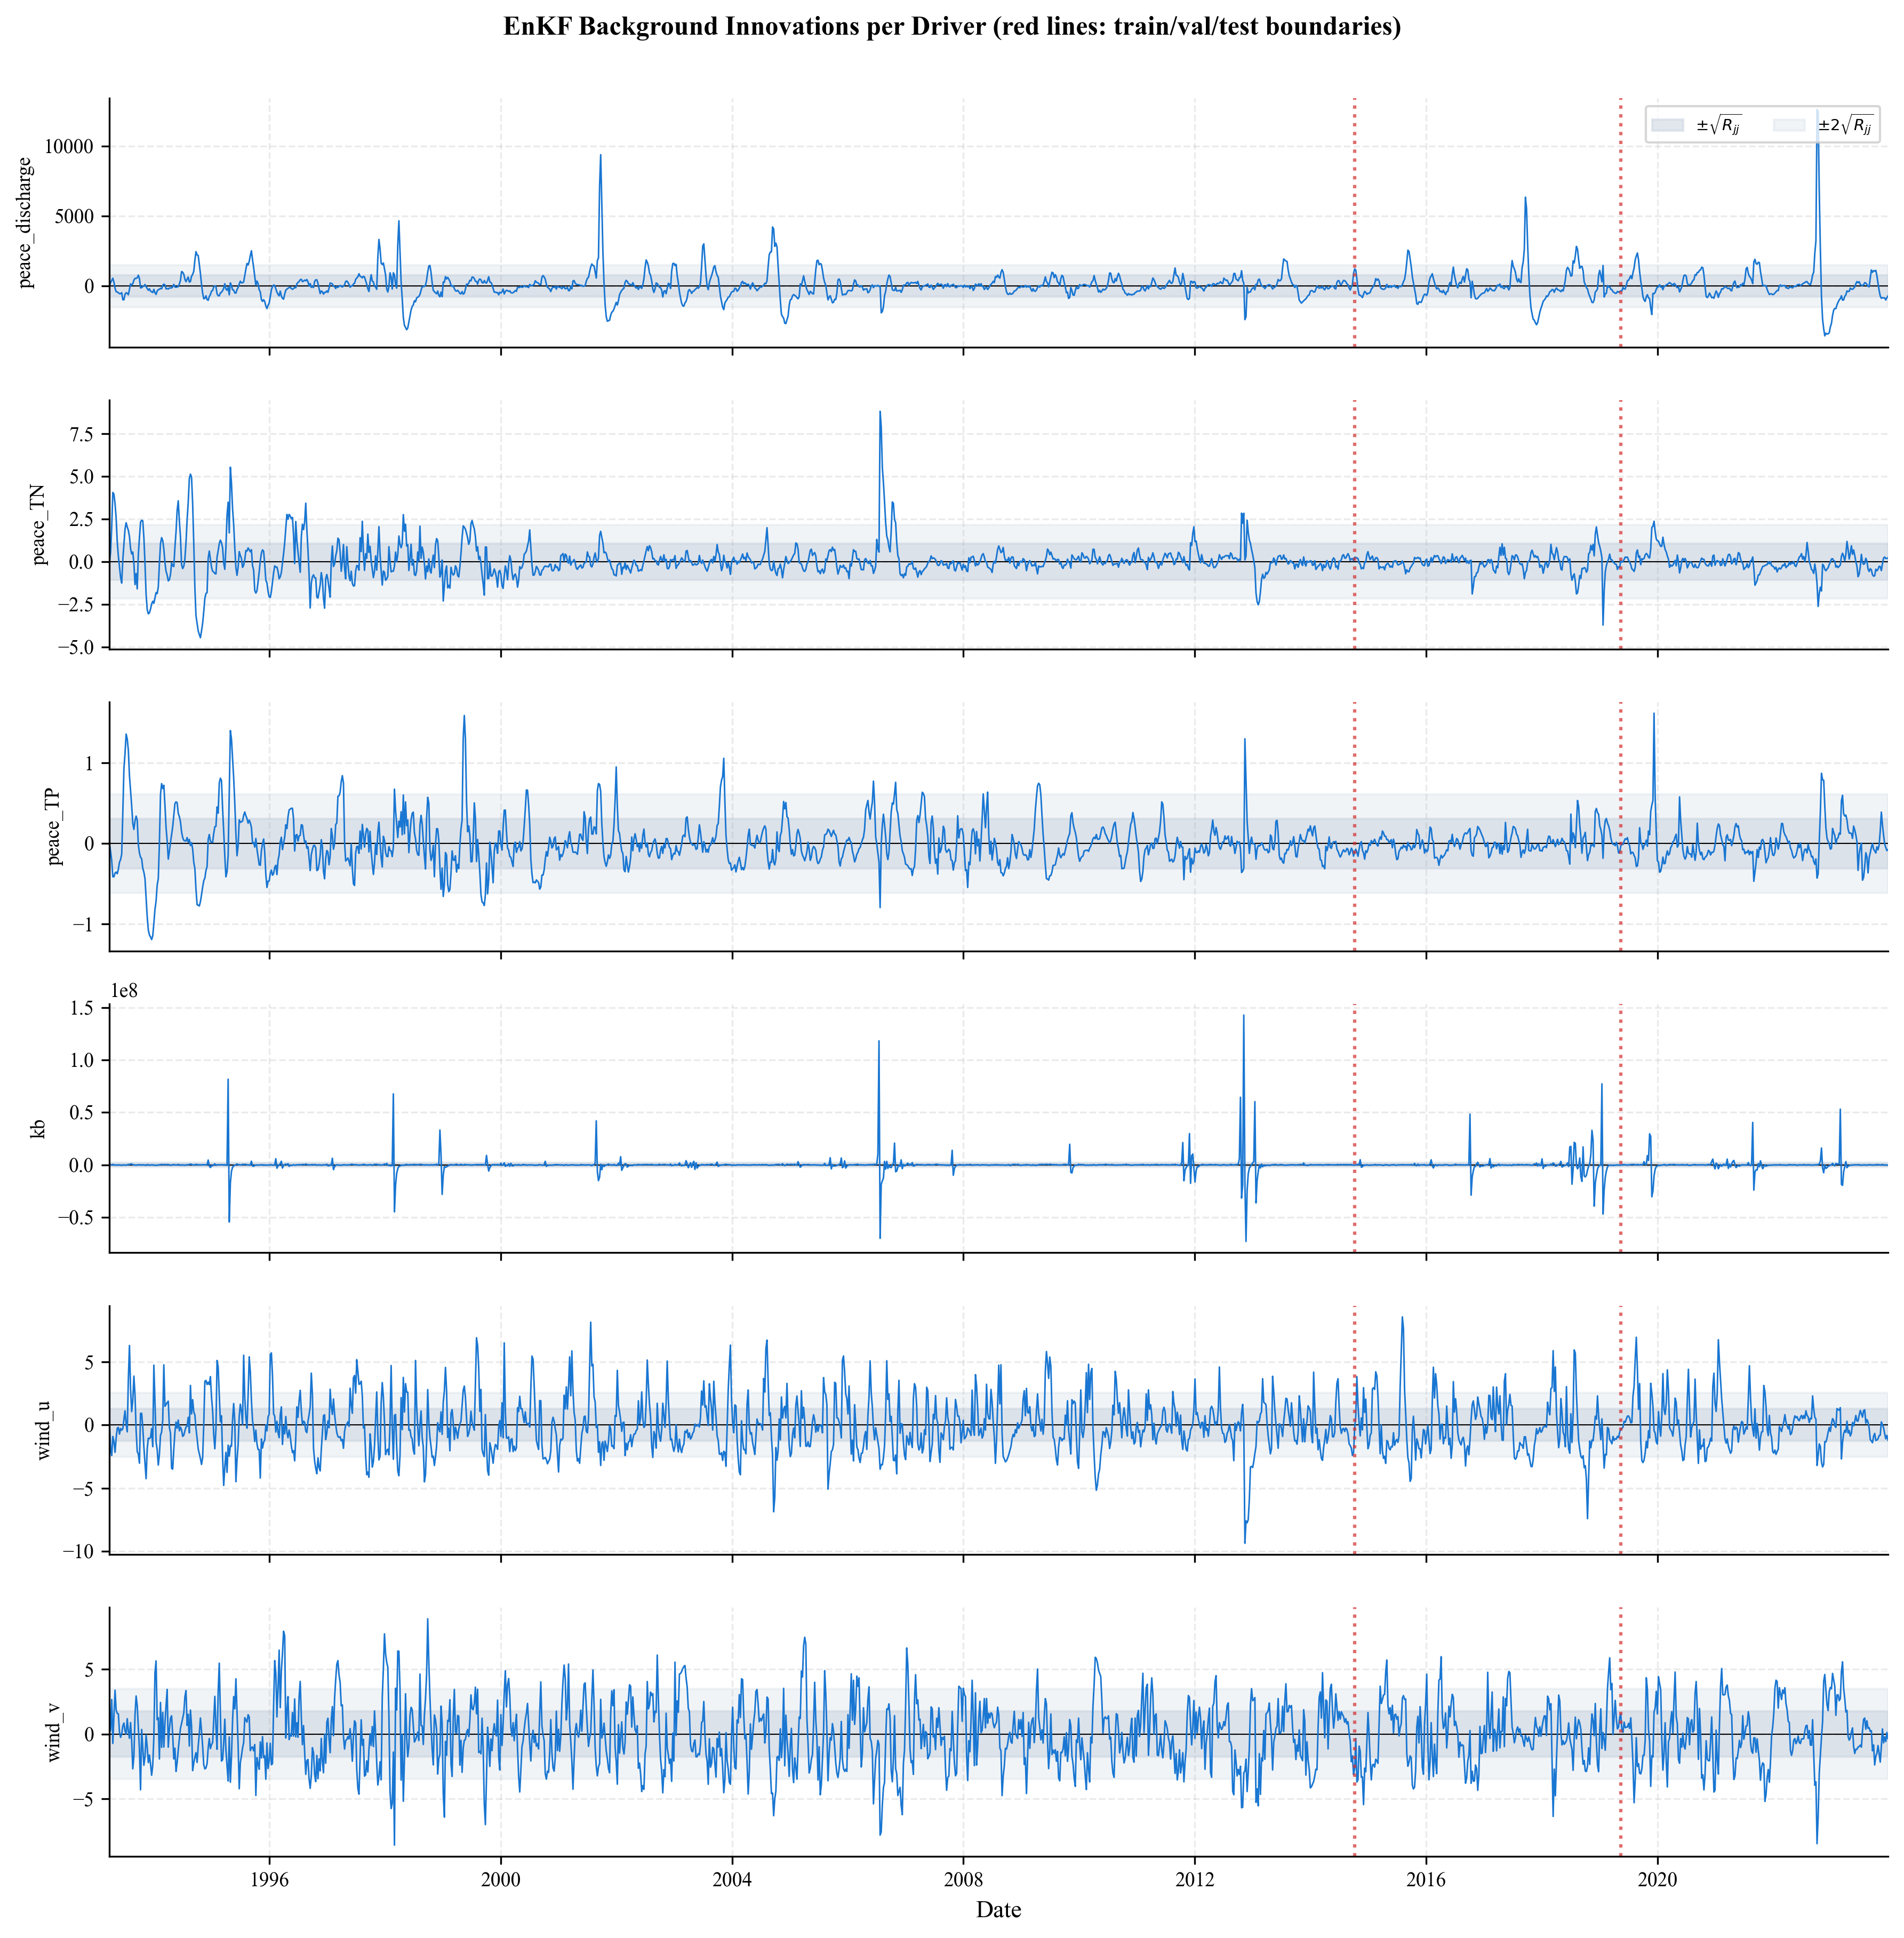

  saved output_refactored/enkf_decomposition\Table4a_innovation_summary.csv
  Innovation magnitude per driver


,driver,sqrt_R_jj,innovation_rmse,innovation_bias,rmse_over_sqrtR,n_assimilations
0,peace_discharge,7.543348e+02,1.035555e+03,34.219970,1.372805,1605
1,peace_TN,1.076231e+00,9.650138e-01,0.044810,0.896660,1605
2,peace_TP,3.061234e-01,2.794481e-01,0.002744,0.912861,1605
3,kb,1.124980e+06,8.357490e+06,27748.696944,7.429015,1605
4,wind_u,1.260440e+00,2.079763e+00,-0.076796,1.650030,1605
5,wind_v,1.731355e+00,2.443368e+00,-0.039020,1.411246,1605


In [5]:
dates = full_df.index
fig, axes = plt.subplots(len(state_vars), 1, figsize=(12, 2.0 * len(state_vars)),
                         sharex=True)
if len(state_vars) == 1:
    axes = [axes]

for ax, j, var in zip(axes, range(len(state_vars)), state_vars):
    series = result["innovations_background"][:, j]
    sigma_R = float(np.sqrt(R_diag[j]))
    ax.axhline(0, color="black", lw=0.5)
    ax.axhspan(-sigma_R, sigma_R, color="#cbd5e1", alpha=0.55, label=r"$\pm\sqrt{R_{jj}}$")
    ax.axhspan(-2 * sigma_R, 2 * sigma_R, color="#cbd5e1", alpha=0.25, label=r"$\pm 2\sqrt{R_{jj}}$")
    ax.plot(dates, series, color="#1976D2", lw=0.7)
    ax.axvline(dates[n_train], color="#D32F2F", linestyle=":", alpha=0.7)
    ax.axvline(dates[n_train + n_val], color="#D32F2F", linestyle=":", alpha=0.7)
    ax.set_ylabel(var, fontsize=9)
    ax.grid(alpha=0.25, linestyle="--")
    if j == 0:
        ax.legend(loc="upper right", fontsize=7, ncol=2, frameon=True)
    ax.set_xlim(dates[0], dates[-1])

axes[-1].set_xlabel("Date")
fig.suptitle("EnKF Background Innovations per Driver (red lines: train/val/test boundaries)",
             fontweight="bold", y=1.005)
plt.tight_layout()
savefig(fig, "Fig4a_innovations_time_series")
plt.show()

# Summary table
rows = []
for j, var in enumerate(state_vars):
    d = result["innovations_background"][:, j]
    d = d[~np.isnan(d)]
    rmse = float(np.sqrt(np.mean(d ** 2))) if len(d) else np.nan
    bias = float(d.mean()) if len(d) else np.nan
    rows.append({
        "driver": var,
        "sqrt_R_jj": float(np.sqrt(R_diag[j])),
        "innovation_rmse": rmse,
        "innovation_bias": bias,
        "rmse_over_sqrtR": rmse / max(float(np.sqrt(R_diag[j])), 1e-12),
        "n_assimilations": int(len(d)),
    })
innovation_summary = pd.DataFrame(rows)
save_table(innovation_summary, "Table4a_innovation_summary.csv",
           "Innovation magnitude per driver")


## Kalman gain over time

`K_jj` is the per-driver weight the analysis places on the observation
(vs. the forecast prior). For a univariate channel this asymptotes to
`Q_jj / (Q_jj + R_jj)` once `P^f` reaches steady state. Departures from
the steady-state value indicate transient conditions where the EnKF is
adjusting its weighting.

Note: the printed `expected_gain_steady_state` is the **univariate** steady-state
value `Q_jj / (Q_jj + R_jj)`. With a random-walk state model the *empirical*
steady state is `mean_K_jj ≈ ½ (-Q_jj/R_jj + √((Q_jj/R_jj)² + 4 Q_jj/R_jj))`,
which is what the EnKF actually converges to and is what should match `mean_gain`.

  saved output_refactored/enkf_decomposition\Fig4b_kalman_gain_time_series.png
  saved output_refactored/enkf_decomposition\Fig4b_kalman_gain_time_series.pdf


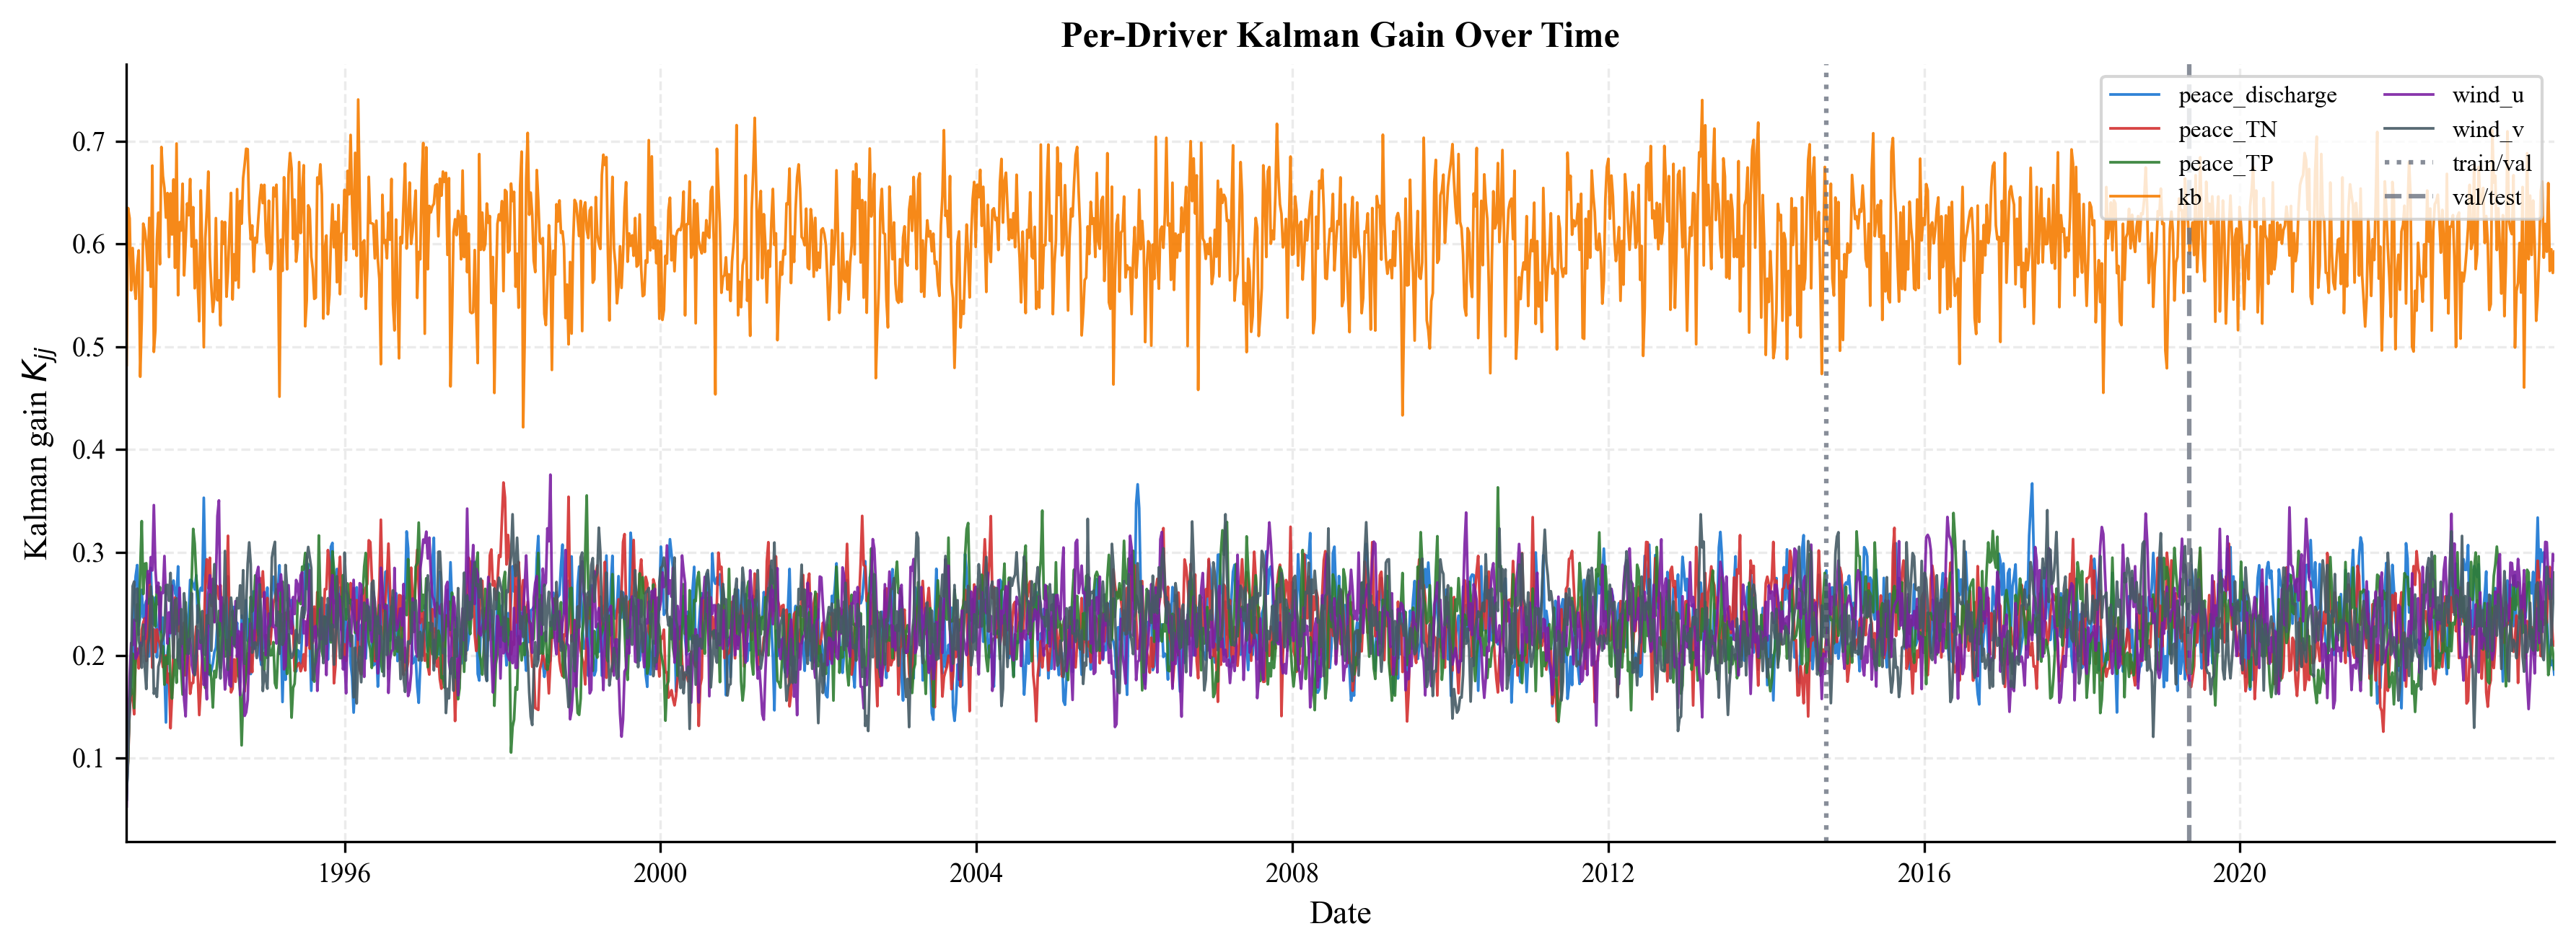

  saved output_refactored/enkf_decomposition\Table4b_kalman_gain_summary.csv
  Kalman gain summary per driver


,driver,mean_gain_empirical,median_gain_empirical,min_gain_empirical,max_gain_empirical,steady_state_gain_theoretical
0,peace_discharge,0.232545,0.231243,0.060199,0.367086,0.197211
1,peace_TN,0.227705,0.227254,0.079665,0.367998,0.197211
2,peace_TP,0.228219,0.227957,0.066995,0.363248,0.197211
3,kb,0.604165,0.605977,0.421758,0.740432,0.381966
4,wind_u,0.230371,0.229075,0.053028,0.375644,0.197211
5,wind_v,0.230322,0.229794,0.059538,0.341102,0.197211


In [6]:
fig, ax = plt.subplots(figsize=(12, 4.5))
COLORS_K = ["#1976D2", "#D32F2F", "#2E7D32", "#F57C00", "#7B1FA2", "#455A64", "#C62828"]
for j, var in enumerate(state_vars):
    ax.plot(dates, result["kalman_gain_diag"][:, j], lw=0.9, alpha=0.9,
            label=var, color=COLORS_K[j % len(COLORS_K)])
ax.axvline(dates[n_train], color="#6B7280", linestyle=":", alpha=0.8, label="train/val")
ax.axvline(dates[n_train + n_val], color="#6B7280", linestyle="--", alpha=0.8, label="val/test")
ax.set_xlim(dates[0], dates[-1])
ax.set_xlabel("Date")
ax.set_ylabel(r"Kalman gain $K_{jj}$")
ax.set_title("Per-Driver Kalman Gain Over Time", fontweight="bold")
ax.legend(frameon=True, loc="upper right", ncol=2, fontsize=8)
ax.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
savefig(fig, "Fig4b_kalman_gain_time_series")
plt.show()

# Empirical steady-state Riccati solution for univariate random-walk + identity obs
def riccati_steady_state(q, r):
    # P_inf satisfies P_inf = (P_inf + q) * r / (P_inf + q + r) so P_inf solves
    # P_inf**2 + q * P_inf - q * r = 0 (after algebra)
    return 0.5 * (-q + np.sqrt(q ** 2 + 4 * q * r))

rows = []
for j, var in enumerate(state_vars):
    K = result["kalman_gain_diag"][:, j]
    q = float(Q_diag[j]); r = float(R_diag[j])
    P_inf = riccati_steady_state(q, r)
    K_inf = P_inf / (P_inf + r)
    rows.append({
        "driver": var,
        "mean_gain_empirical": float(K.mean()),
        "median_gain_empirical": float(np.median(K)),
        "min_gain_empirical": float(K.min()),
        "max_gain_empirical": float(K.max()),
        "steady_state_gain_theoretical": float(K_inf),
    })
gain_summary = pd.DataFrame(rows)
save_table(gain_summary, "Table4b_kalman_gain_summary.csv",
           "Kalman gain summary per driver")


## Variance reduction by assimilation

The trace of the analysis covariance `P^a` relative to the forecast
covariance `P^f` quantifies how much each observation step shrinks the
state uncertainty. Values near 1 mean the EnKF essentially ignored
observations (R dominates); values near 0 mean the observations
dominated (R << P^f).

  saved output_refactored/enkf_decomposition\Fig4c_variance_reduction.png
  saved output_refactored/enkf_decomposition\Fig4c_variance_reduction.pdf


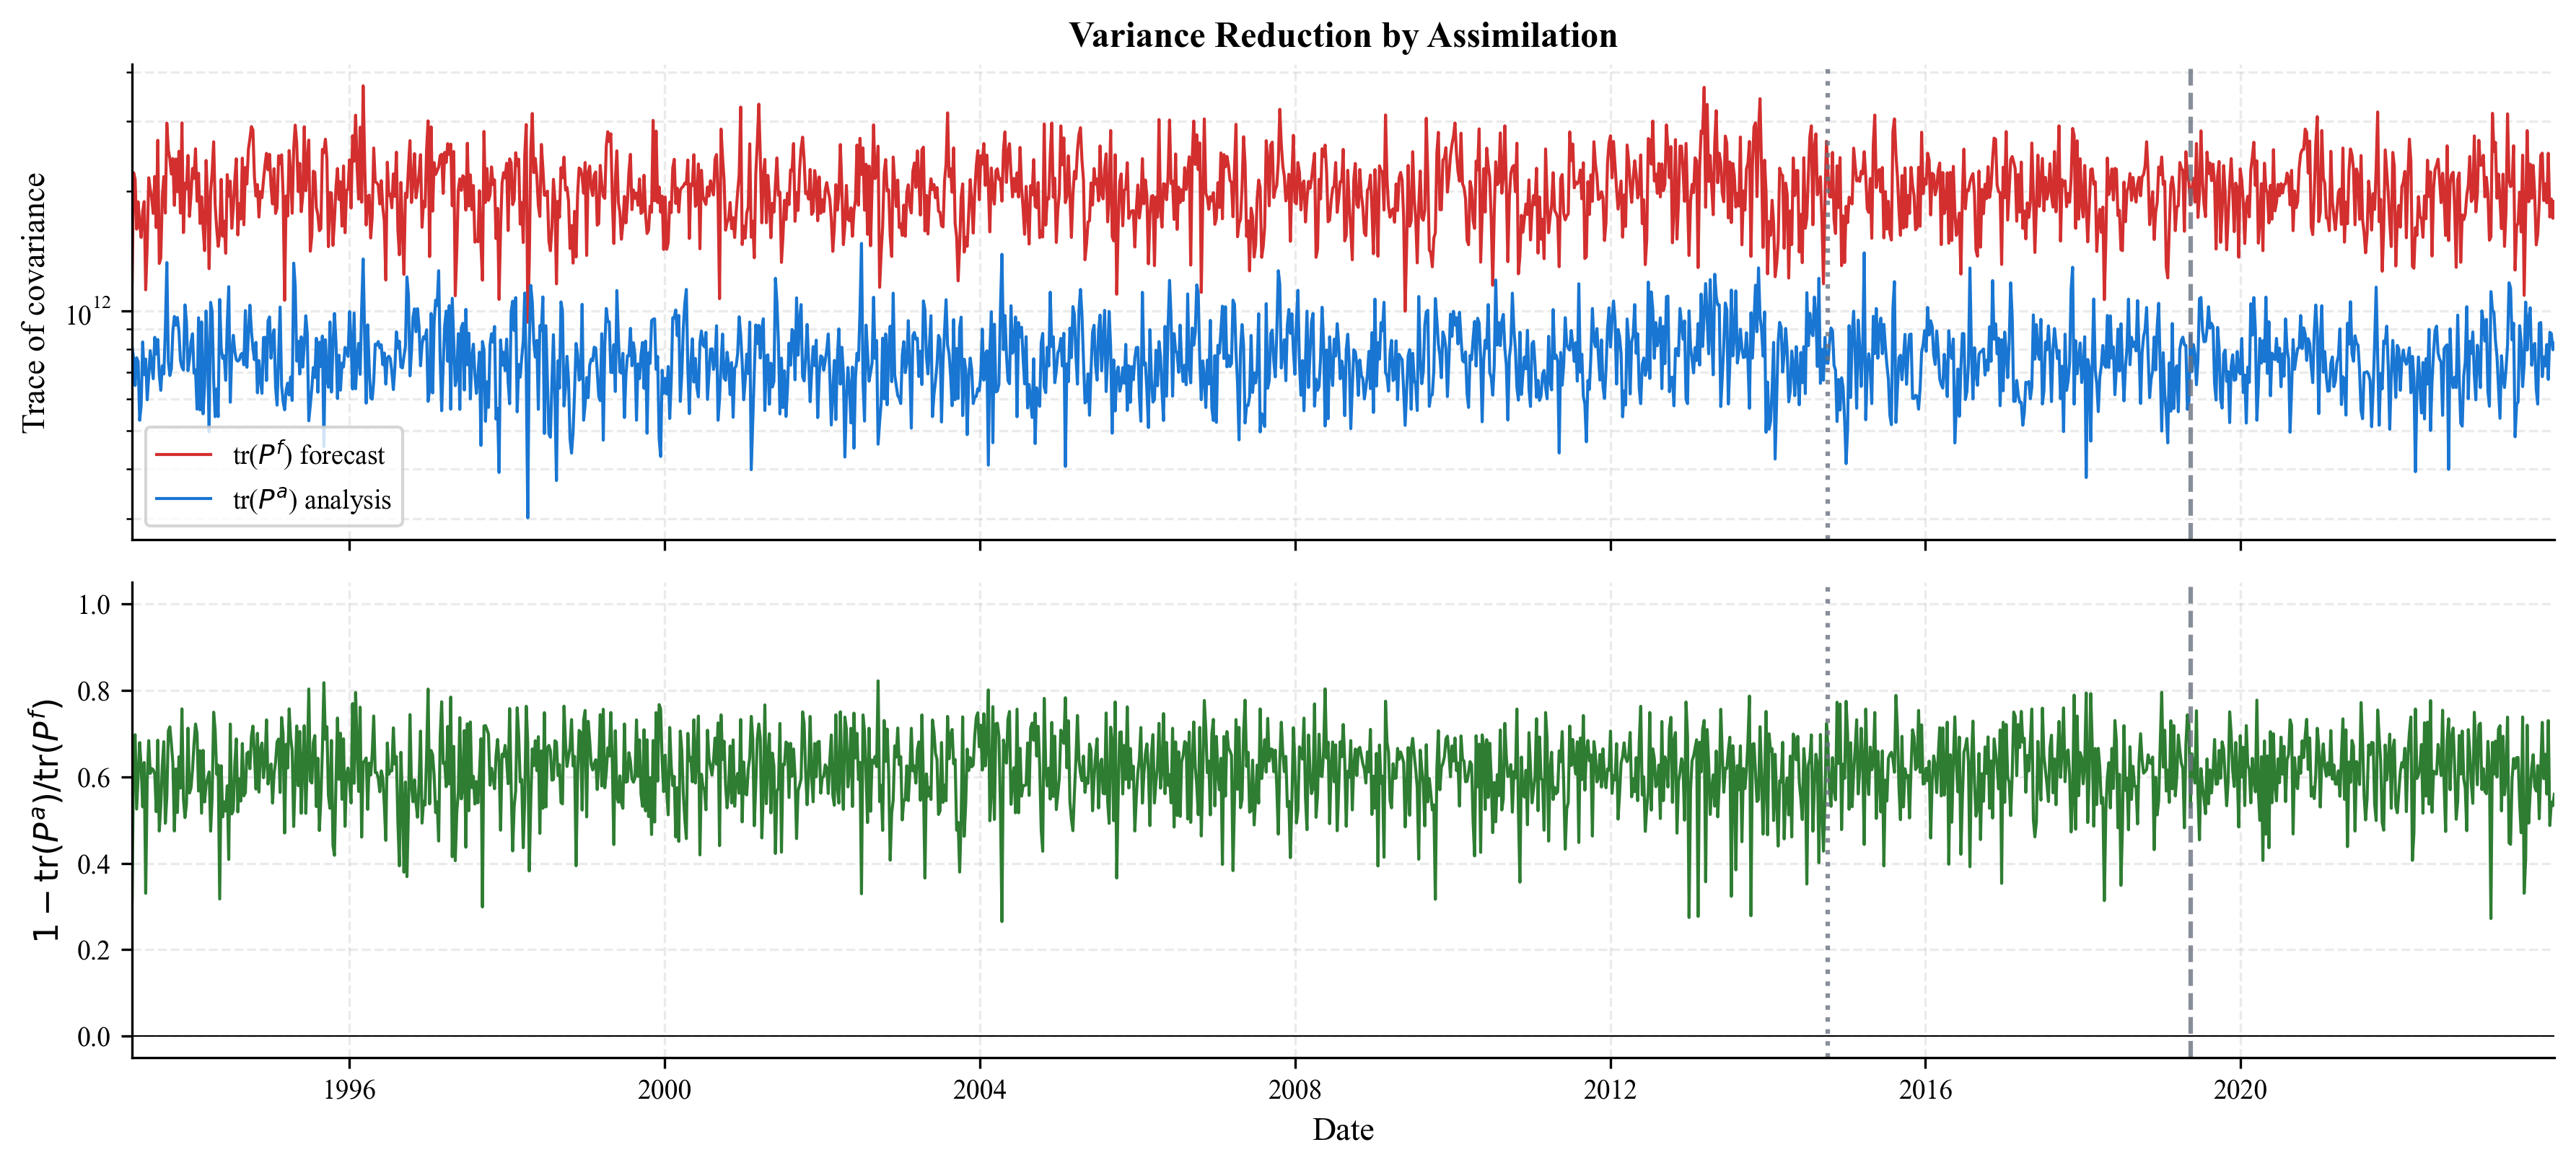

  saved output_refactored/enkf_decomposition\Table4c_variance_reduction_summary.csv
  Variance reduction by split


,mean_reduction_train,mean_reduction_val,mean_reduction_test,mean_reduction_overall
0,0.610345,0.615085,0.611159,0.611176


In [7]:
trace_f = result["P_forecast_diag"].sum(axis=1)
trace_a = result["P_analysis_diag"].sum(axis=1)
reduction = 1.0 - trace_a / np.maximum(trace_f, 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
axes[0].plot(dates, trace_f, color="#D32F2F", lw=1.0, label=r"tr($P^f$) forecast")
axes[0].plot(dates, trace_a, color="#1976D2", lw=1.0, label=r"tr($P^a$) analysis")
axes[0].set_ylabel("Trace of covariance")
axes[0].set_yscale("log")
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.25, linestyle="--", which="both")
axes[0].set_title("Variance Reduction by Assimilation", fontweight="bold")

axes[1].plot(dates, reduction, color="#2E7D32", lw=1.0)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_ylabel(r"$1 - \mathrm{tr}(P^a) / \mathrm{tr}(P^f)$")
axes[1].set_xlabel("Date")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(alpha=0.25, linestyle="--")

for ax in axes:
    ax.axvline(dates[n_train], color="#6B7280", linestyle=":", alpha=0.8)
    ax.axvline(dates[n_train + n_val], color="#6B7280", linestyle="--", alpha=0.8)
    ax.set_xlim(dates[0], dates[-1])

plt.tight_layout()
savefig(fig, "Fig4c_variance_reduction")
plt.show()

reduction_summary = pd.DataFrame([{
    "mean_reduction_train": float(reduction[:n_train].mean()),
    "mean_reduction_val": float(reduction[n_train:n_train + n_val].mean()),
    "mean_reduction_test": float(reduction[n_train + n_val:].mean()),
    "mean_reduction_overall": float(reduction.mean()),
}])
save_table(reduction_summary, "Table4c_variance_reduction_summary.csv",
           "Variance reduction by split")


## Desroziers consistency diagnostics

Desroziers, Berre, Chapnik & Poli (2005, QJRMS) showed two consistency
identities that a well-tuned EnKF must satisfy at steady state:

- **Test 1 (Innovation variance):** `E[d^b (d^b)^T] = HBH^T + R`. With H=I, this
  is `E[d^b (d^b)^T] = P^f + R`. The empirical innovation variance must equal
  the assumed forecast-plus-observation variance.
- **Test 2 (R consistency):** `E[d^a (d^b)^T] = R`. The covariance of analysis
  with background innovations is an empirical estimator of R itself.

Both tests are reported as a ratio of empirical to assumed value with 95%
bootstrap CIs. A consistent EnKF has ratios overlapping 1.0. Ratios > 1
indicate underestimated noise; ratios < 1 indicate overestimated noise.

  saved output_refactored/enkf_decomposition\Table4d_desroziers_consistency.csv
  Desroziers consistency diagnostics (95% bootstrap CIs)


,driver,empirical_innovation_variance,assumed_innovation_variance,innovation_ratio,empirical_R_diag,assumed_R_diag,R_ratio,innovation_ratio_ci_lo,innovation_ratio_ci_hi,R_ratio_ci_lo,R_ratio_ci_hi,innovation_consistent_95,R_consistent_95
0,peace_discharge,1.072374e+06,7.487799e+05,1.432162,8.185320e+05,5.690211e+05,1.438492,1.079133,1.889406,1.089672,1.887706,False,False
1,peace_TN,9.312515e-01,1.514628e+00,0.614838,7.459145e-01,1.158273e+00,0.643988,0.506326,0.740730,0.529603,0.781379,False,False
2,peace_TP,7.809126e-02,1.225892e-01,0.637016,6.073373e-02,9.371154e-02,0.648092,0.556917,0.724917,0.566223,0.735643,False,False
3,kb,6.984764e+13,3.293239e+12,21.209408,2.845015e+13,1.265579e+12,22.479949,12.357216,32.684706,12.859935,35.503427,False,False
4,wind_u,4.325414e+00,2.085026e+00,2.074513,3.354110e+00,1.588708e+00,2.111218,1.891559,2.280624,1.915264,2.321286,False,False
5,wind_v,5.970046e+00,3.932429e+00,1.518157,4.633191e+00,2.997591e+00,1.545638,1.409473,1.627827,1.438252,1.658136,False,False


  saved output_refactored/enkf_decomposition\Fig4d_desroziers_consistency.png
  saved output_refactored/enkf_decomposition\Fig4d_desroziers_consistency.pdf


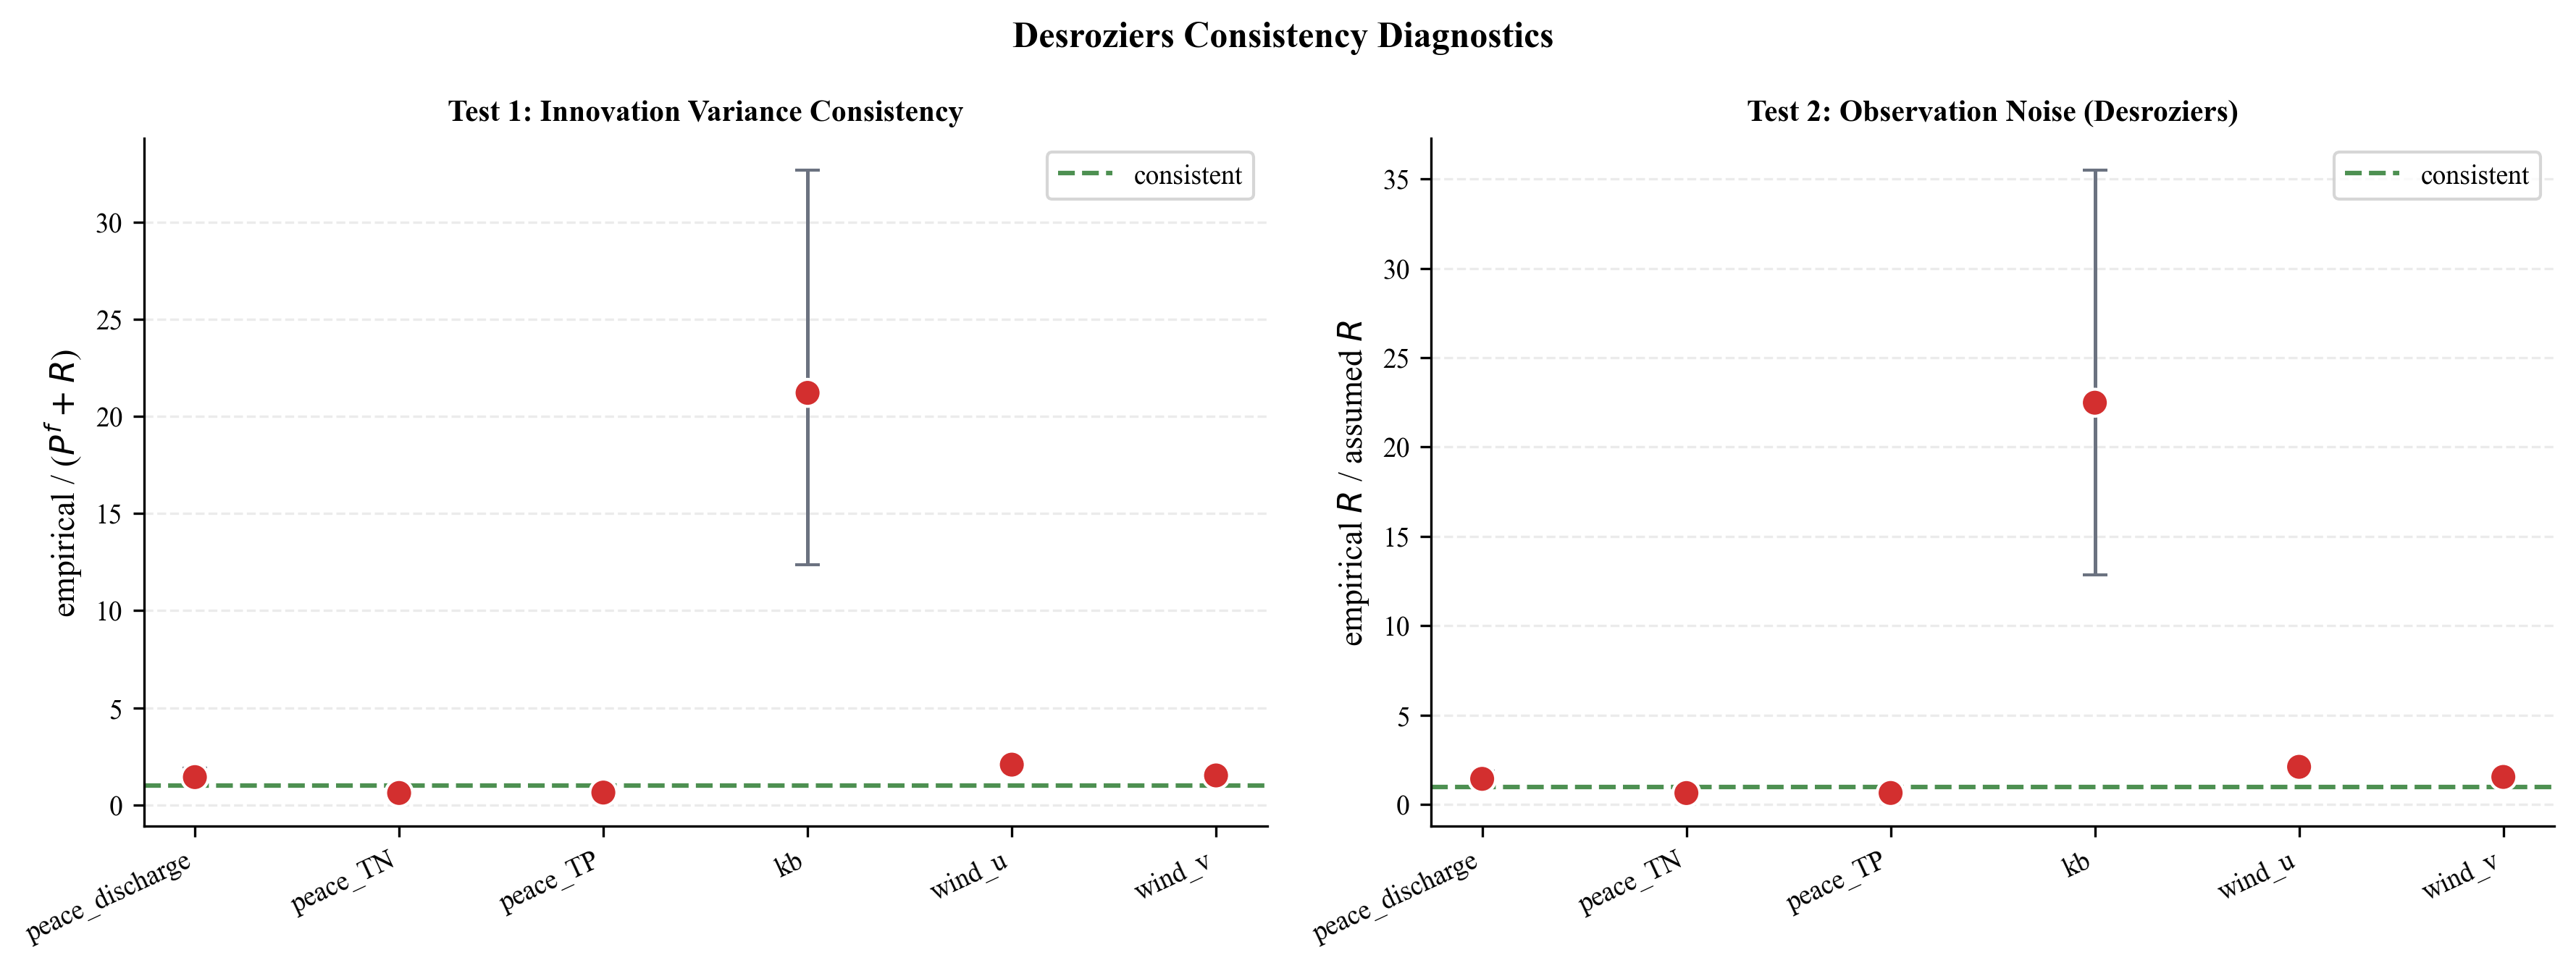


Interpretation:
- Blue marker + CI overlapping 1.0 -> noise specification is consistent with empirical innovations.
- Red marker -> Q or R needs adjustment; see notebook 01 estimate_enkf_noise() configuration.


In [8]:
valid = result["obs_used_mask"]
d_b = result["innovations_background"][valid]
d_a = result["innovations_analysis"][valid]
P_f_valid = result["P_forecast_diag"][valid]
n_valid = len(d_b)
n_drivers = len(state_vars)

# Empirical estimators (Desroziers)
emp_inn_cov = (d_b.T @ d_b) / n_valid
emp_R_cov = (d_a.T @ d_b) / n_valid
mean_P_f_diag = P_f_valid.mean(axis=0)

rows = []
for j, var in enumerate(state_vars):
    emp_inn_var = float(emp_inn_cov[j, j])
    assumed_inn_var = float(mean_P_f_diag[j] + R_diag[j])
    rows.append({
        "driver": var,
        "empirical_innovation_variance": emp_inn_var,
        "assumed_innovation_variance": assumed_inn_var,
        "innovation_ratio": emp_inn_var / max(assumed_inn_var, 1e-12),
        "empirical_R_diag": float(emp_R_cov[j, j]),
        "assumed_R_diag": float(R_diag[j]),
        "R_ratio": float(emp_R_cov[j, j]) / max(float(R_diag[j]), 1e-12),
    })
desroziers = pd.DataFrame(rows)

# Bootstrap CIs (n_boot=2000)
N_BOOT = 2000
rng = np.random.default_rng(SEED)
inn_ratio_boots = np.zeros((n_drivers, N_BOOT))
R_ratio_boots = np.zeros((n_drivers, N_BOOT))
for b in range(N_BOOT):
    idx = rng.choice(n_valid, n_valid, replace=True)
    db_b = d_b[idx]
    da_b = d_a[idx]
    Pf_b = P_f_valid[idx]
    for j in range(n_drivers):
        emp_inn = float(np.mean(db_b[:, j] ** 2))
        emp_R = float(np.mean(da_b[:, j] * db_b[:, j]))
        denom_inn = max(float(Pf_b[:, j].mean() + R_diag[j]), 1e-12)
        inn_ratio_boots[j, b] = emp_inn / denom_inn
        R_ratio_boots[j, b] = emp_R / max(float(R_diag[j]), 1e-12)

desroziers["innovation_ratio_ci_lo"] = np.percentile(inn_ratio_boots, 2.5, axis=1)
desroziers["innovation_ratio_ci_hi"] = np.percentile(inn_ratio_boots, 97.5, axis=1)
desroziers["R_ratio_ci_lo"] = np.percentile(R_ratio_boots, 2.5, axis=1)
desroziers["R_ratio_ci_hi"] = np.percentile(R_ratio_boots, 97.5, axis=1)
desroziers["innovation_consistent_95"] = (desroziers["innovation_ratio_ci_lo"] <= 1.0) & (desroziers["innovation_ratio_ci_hi"] >= 1.0)
desroziers["R_consistent_95"] = (desroziers["R_ratio_ci_lo"] <= 1.0) & (desroziers["R_ratio_ci_hi"] >= 1.0)

save_table(desroziers, "Table4d_desroziers_consistency.csv",
           "Desroziers consistency diagnostics (95% bootstrap CIs)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(n_drivers)
inn_vals = desroziers["innovation_ratio"].values
inn_err = np.vstack([inn_vals - desroziers["innovation_ratio_ci_lo"].values,
                     desroziers["innovation_ratio_ci_hi"].values - inn_vals])
colors_inn = np.where(desroziers["innovation_consistent_95"].values, "#1976D2", "#D32F2F")
axes[0].errorbar(x, inn_vals, yerr=inn_err, fmt="none", ecolor="#6B7280", elinewidth=1.2, capsize=4)
axes[0].scatter(x, inn_vals, c=colors_inn, s=80, edgecolor="white", zorder=3)
axes[0].axhline(1.0, color="#2E7D32", linestyle="--", alpha=0.85, label="consistent")
axes[0].set_xticks(x); axes[0].set_xticklabels(state_vars, rotation=25, ha="right")
axes[0].set_ylabel(r"empirical / ($P^f + R$)")
axes[0].set_title("Test 1: Innovation Variance Consistency", fontweight="bold", fontsize=10)
axes[0].grid(axis="y", alpha=0.25, linestyle="--")
axes[0].legend(frameon=True)

R_vals = desroziers["R_ratio"].values
R_err = np.vstack([R_vals - desroziers["R_ratio_ci_lo"].values,
                   desroziers["R_ratio_ci_hi"].values - R_vals])
colors_R = np.where(desroziers["R_consistent_95"].values, "#1976D2", "#D32F2F")
axes[1].errorbar(x, R_vals, yerr=R_err, fmt="none", ecolor="#6B7280", elinewidth=1.2, capsize=4)
axes[1].scatter(x, R_vals, c=colors_R, s=80, edgecolor="white", zorder=3)
axes[1].axhline(1.0, color="#2E7D32", linestyle="--", alpha=0.85, label="consistent")
axes[1].set_xticks(x); axes[1].set_xticklabels(state_vars, rotation=25, ha="right")
axes[1].set_ylabel(r"empirical $R$ / assumed $R$")
axes[1].set_title("Test 2: Observation Noise (Desroziers)", fontweight="bold", fontsize=10)
axes[1].grid(axis="y", alpha=0.25, linestyle="--")
axes[1].legend(frameon=True)

fig.suptitle("Desroziers Consistency Diagnostics", fontweight="bold")
plt.tight_layout()
savefig(fig, "Fig4d_desroziers_consistency")
plt.show()

print("\nInterpretation:")
print("- Blue marker + CI overlapping 1.0 -> noise specification is consistent with empirical innovations.")
print("- Red marker -> Q or R needs adjustment; see notebook 01 estimate_enkf_noise() configuration.")


## Persist diagnostics for notebook 04b

The ensemble member trajectories produced here are the input that notebook 04b
needs to run MC dropout per-member and produce the 3-D variance decomposition.
We also save the per-step gains/innovations for any future paper-ready figures.

In [9]:
ENKF_DIAGNOSTICS_PATH = os.path.join(INTERMEDIATE_DIR, "enkf_diagnostics.npz")
np.savez(
    ENKF_DIAGNOSTICS_PATH,
    members=result["members"].astype(np.float32),
    x_forecast_mean=result["x_forecast_mean"].astype(np.float32),
    x_analysis_mean=result["x_analysis_mean"].astype(np.float32),
    innovations_background=result["innovations_background"].astype(np.float32),
    innovations_analysis=result["innovations_analysis"].astype(np.float32),
    kalman_gain_diag=result["kalman_gain_diag"].astype(np.float32),
    P_forecast_diag=result["P_forecast_diag"].astype(np.float32),
    P_analysis_diag=result["P_analysis_diag"].astype(np.float32),
    obs_used_mask=result["obs_used_mask"],
    state_vars=np.array(state_vars),
    Q_diag=Q_diag.astype(np.float32),
    R_diag=R_diag.astype(np.float32),
    n_train=np.int64(n_train),
    n_val=np.int64(n_val),
    n_test=np.int64(n_test),
)
print(f"Saved EnKF diagnostics -> {ENKF_DIAGNOSTICS_PATH}")
print(f"  ensemble members shape: {result['members'].shape}  (n_enkf, T, n_drivers)")
print(f"\nRun notebook 04b next to consume members[] and produce the 3-D MC-dropout tensor.")


Saved EnKF diagnostics -> output_refactored/intermediate\enkf_diagnostics.npz
  ensemble members shape: (50, 1605, 6)  (n_enkf, T, n_drivers)

Run notebook 04b next to consume members[] and produce the 3-D MC-dropout tensor.
